In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("marketing_campaign_performance.csv")

df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86


In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (10000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CampaignID   10000 non-null  str    
 1   StartDate    10000 non-null  str    
 2   EndDate      10000 non-null  str    
 3   Channel      10000 non-null  str    
 4   Impressions  10000 non-null  int64  
 5   Clicks       10000 non-null  int64  
 6   Leads        10000 non-null  int64  
 7   Conversions  10000 non-null  int64  
 8   Cost_USD     10000 non-null  float64
 9   Revenue_USD  10000 non-null  float64
 10  ROI          10000 non-null  float64
dtypes: float64(3), int64(4), str(4)
memory usage: 859.5 KB


,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,152260.637900,8338.993300,2512.463600,1010.700000,2552.356991,5102.648930,1.001576
std,85251.707621,6546.326431,2321.031302,1019.402613,1427.694545,3309.326705,0.578806
min,5043.000000,72.000000,10.000000,4.000000,100.230000,113.640000,0.000000
25%,78956.000000,2981.000000,779.000000,295.000000,1319.622500,2385.742500,0.500000
50%,151505.500000,6588.500000,1777.000000,670.000000,2529.675000,4659.365000,0.990000
75%,225853.250000,12404.250000,3550.250000,1391.000000,3821.307500,7241.245000,1.510000
max,299997.000000,29578.000000,13833.000000,7987.000000,4998.420000,14871.340000,2.000000


In [5]:
df.isnull().sum()

CampaignID     0
StartDate      0
EndDate        0
Channel        0
Impressions    0
Clicks         0
Leads          0
Conversions    0
Cost_USD       0
Revenue_USD    0
ROI            0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

New Shape: (10000, 11)


In [7]:
df["StartDate"] = pd.to_datetime(df["StartDate"])
df["EndDate"] = pd.to_datetime(df["EndDate"])

In [8]:
# Campaign Duration
df["Campaign_Duration"] = (
    df["EndDate"] - df["StartDate"]
).dt.days

# CTR
df["CTR"] = (
    df["Clicks"] /
    df["Impressions"]
) * 100

# Lead Conversion Rate
df["Lead_Conversion_Rate"] = (
    df["Leads"] /
    df["Clicks"]
) * 100

# Conversion Rate
df["Conversion_Rate"] = (
    df["Conversions"] /
    df["Clicks"]
) * 100

# Cost Per Click
df["CPC"] = (
    df["Cost_USD"] /
    df["Clicks"]
)

# Cost Per Lead
df["CPL"] = (
    df["Cost_USD"] /
    df["Leads"]
)

# Cost Per Conversion
df["Cost_Per_Conversion"] = (
    df["Cost_USD"] /
    df["Conversions"]
)

# Revenue Per Click
df["Revenue_Per_Click"] = (
    df["Revenue_USD"] /
    df["Clicks"]
)

# ROI
df["ROI"] = (
    (
        df["Revenue_USD"]
        - df["Cost_USD"]
    )
    /
    df["Cost_USD"]
) * 100

In [9]:
df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,Campaign_Duration,CTR,Lead_Conversion_Rate,Conversion_Rate,CPC,CPL,Cost_Per_Conversion,Revenue_Per_Click
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,112.470662,6,7.950055,49.895007,23.094065,0.045099,0.090388,0.195285,0.095823
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,196.102045,9,7.907058,41.670349,15.769206,0.250294,0.600651,1.587230,0.741124
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,90.149842,8,6.884047,48.810535,20.615366,0.060711,0.124380,0.294492,0.115441
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,76.408037,13,1.708637,37.949102,12.799401,0.468799,1.235335,3.662661,0.826999
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,185.915656,9,1.455484,36.606498,13.598075,1.187841,3.244892,8.735363,3.396224


In [10]:
print("Total Campaigns :", df["CampaignID"].nunique())

print("Total Cost :", round(df["Cost_USD"].sum(), 2))

print("Total Revenue :", round(df["Revenue_USD"].sum(), 2))

print("Average ROI :", round(df["ROI"].mean(), 2))

print("Total Conversions :", df["Conversions"].sum())

Total Campaigns : 10000
Total Cost : 25523569.91
Total Revenue : 51026489.3
Average ROI : 100.15
Total Conversions : 10107000


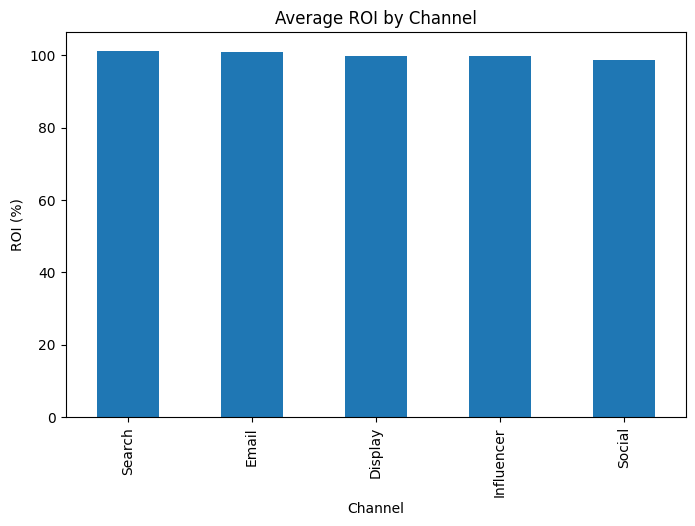

In [11]:
channel_roi = (
    df.groupby("Channel")["ROI"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

channel_roi.plot(kind="bar")

plt.title("Average ROI by Channel")
plt.ylabel("ROI (%)")

plt.show()

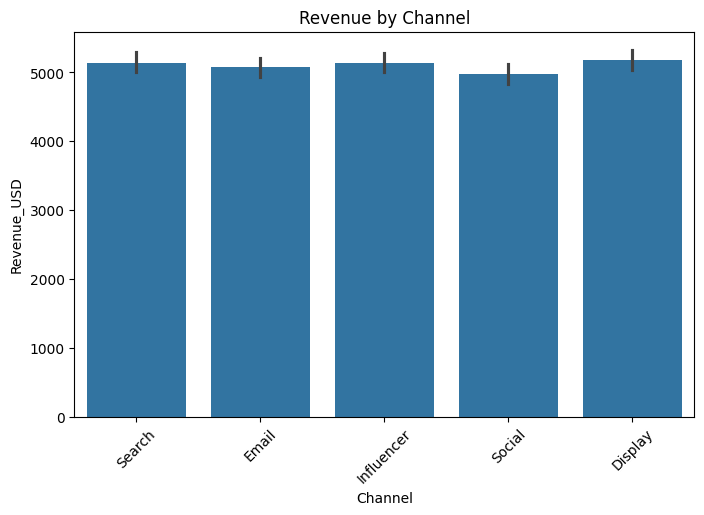

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Channel",
    y="Revenue_USD"
)

plt.xticks(rotation=45)

plt.title("Revenue by Channel")

plt.show()

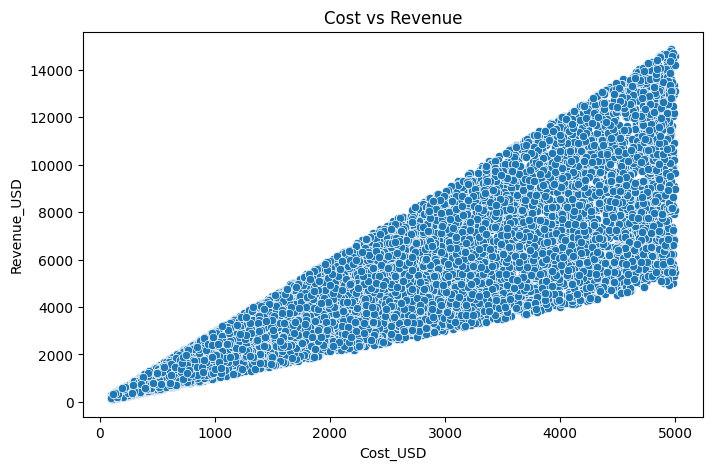

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Cost_USD",
    y="Revenue_USD"
)

plt.title("Cost vs Revenue")

plt.show()

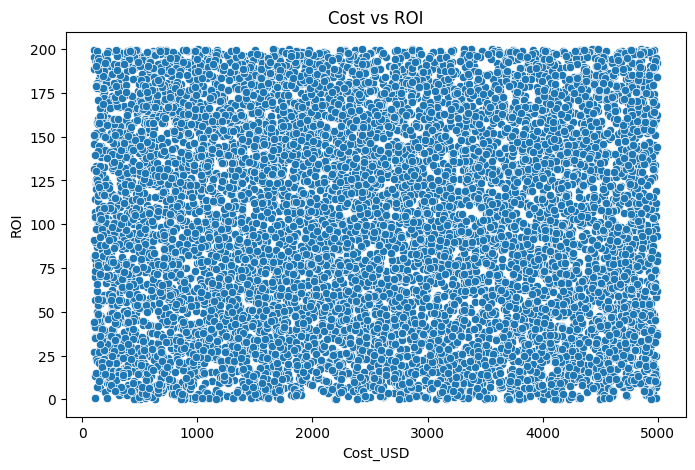

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Cost_USD",
    y="ROI"
)

plt.title("Cost vs ROI")

plt.show()

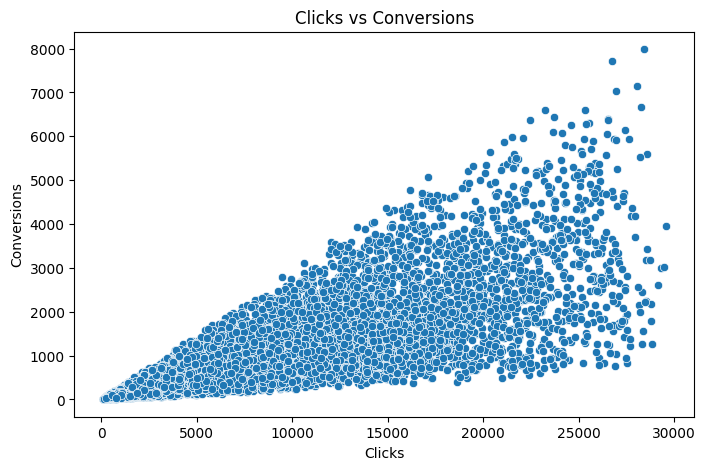

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Clicks",
    y="Conversions"
)

plt.title("Clicks vs Conversions")

plt.show()

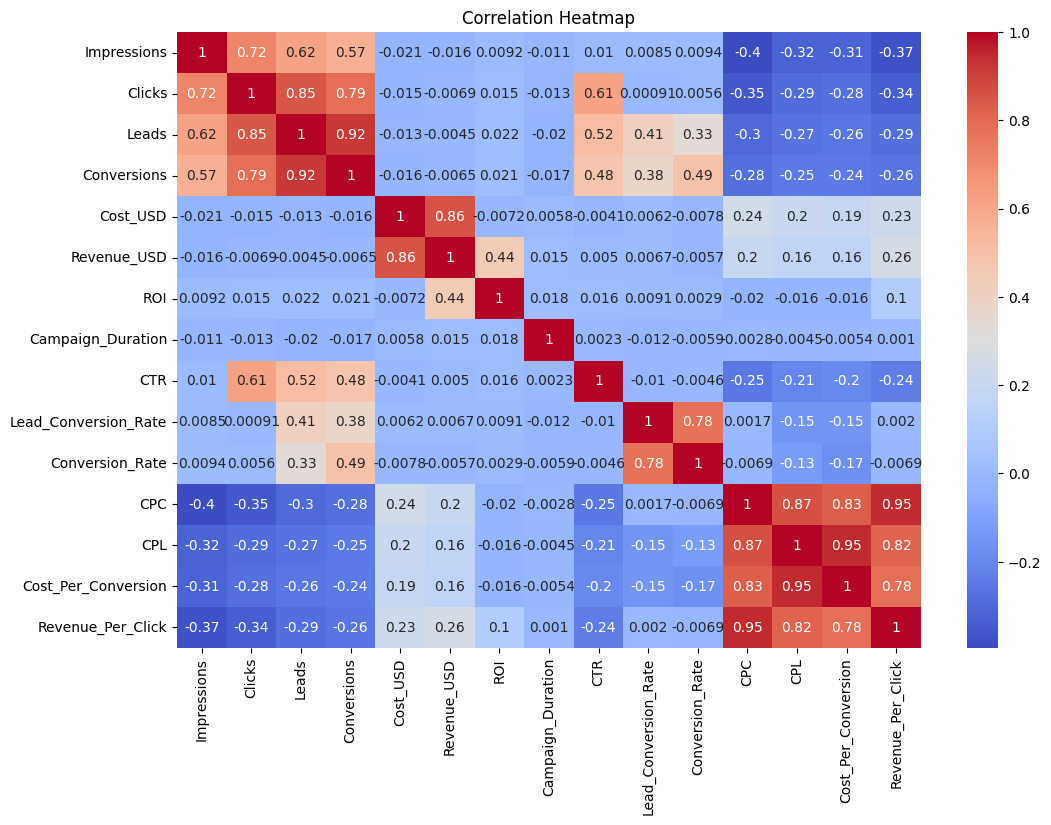

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
print(
    df.groupby("Channel")["Revenue_USD"]
    .sum()
    .sort_values(ascending=False)
)

Channel
Display       10715125.21
Influencer    10558118.99
Email         10130542.61
Search         9897677.79
Social         9725024.70
Name: Revenue_USD, dtype: float64


In [18]:
df.to_csv(
    "marketing_campaign_processed.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
